# Supply Chain Resilience Analysis with Apache Spark and Neo4j

Supply chains are graphs. Suppliers, warehouses, distribution centers and retailers are nodes; shipping routes are relationships. When we model them that way, we unlock a powerful set of tools for understanding how resilient or fragile our network really is.

In this notebook we'll build a synthetic supply chain, load it into Neo4j via Apache Spark, then use NetworkX to identify the most critical nodes in the network. We'll simulate a real-world disruption - a key warehouse goes offline - and use Neo4j's native Cypher to find alternative routes through the network. Throughout, we'll use Plotly for rich interactive visualizations.

## What each tool does in this stack

| Tool | Role |
|------|------|
| Apache Spark (local) | Data generation, transformation and loading into Neo4j |
| Neo4j (remote) | Graph storage and native variable-length path queries |
| NetworkX | Betweenness centrality - identifying the most critical nodes |
| Plotly | Interactive visualization throughout |

> **Note:** NetworkX loads the entire graph into memory to compute betweenness centrality. For a demo dataset this is perfectly fine. As your supply chain grows into the hundreds of thousands of nodes, you will want to move this computation to Neo4j's Graph Data Science (GDS) library or Aura Graph Analytics on AuraDB - both run the algorithm natively inside the database without pulling data out. We'll return to this point at the end.

## Before running the notebook

Export the following in your shell:

```bash
export NEO4J_URI=neo4j+s://xxxx.databases.neo4j.io
export NEO4J_USERNAME=your_username_here
export NEO4J_PASSWORD=your_password_here
export NEO4J_DATABASE=your_database_name_here
```

> **Note:** PySpark 3.5.x requires Java 17 or 21. Java 23 and later removed APIs that Spark's Hadoop dependency relies on. If you have a newer Java installed, point PySpark at Java 21 before starting Jupyter:

```bash
# For example, install Java 21 alongside your existing Java using Homebrew on Apple hardware
brew install openjdk@21

# Set Java 21 for this shell session only
export JAVA_HOME=/opt/homebrew/opt/openjdk@21
export PATH="/opt/homebrew/opt/openjdk@21/bin:$PATH"
```

Your existing Java installation is unaffected outside this shell session.

## 1. Install Dependencies

All library versions are pinned so this notebook produces the same results every time, regardless of when it's run. Execute this cell once.

In [1]:
%pip install faker==40.36.0 \
             neo4j==6.2.0 \
             networkx==3.6.1 \
             numpy==2.2.6 \
             pandas==3.0.5 \
             plotly==6.9.0 \
             pyspark==3.5.9 --quiet

print("Install complete.")

Note: you may need to restart the kernel to use updated packages.
Install complete.


In [2]:
import networkx as nx
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import warnings

from faker import Faker
from neo4j import GraphDatabase
from plotly.subplots import make_subplots
from pyspark.sql import SparkSession

warnings.filterwarnings("ignore")

## 2. Configuration

In [3]:
NEO4J_URI       = os.environ["NEO4J_URI"]
NEO4J_USERNAME  = os.environ["NEO4J_USERNAME"]
NEO4J_PASSWORD  = os.environ["NEO4J_PASSWORD"]
NEO4J_DATABASE  = os.environ["NEO4J_DATABASE"]
SPARK_CONNECTOR = "org.neo4j:neo4j-connector-apache-spark_2.12:5.4.0_for_spark_3"
RANDOM_SEED     = 42

print("Credentials set.")

Credentials set.


In [4]:
driver = GraphDatabase.driver(
    NEO4J_URI,
    auth = (NEO4J_USERNAME, NEO4J_PASSWORD)
)

print(driver.verify_connectivity()) # None is expected
print("Connection created.")

None
Connection created.


## 3. Start the Spark Session

Spark runs in local mode - `local[*]` means it uses all available CPU cores on your machine. No cluster is needed. The Neo4j Spark Connector JAR is resolved automatically from Maven Central the first time this cell runs; subsequent runs use the cached copy.

In [5]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("SupplyChainResilience")
    .config("spark.jars.packages", SPARK_CONNECTOR)
    .config("neo4j.url", NEO4J_URI)
    .config("neo4j.authentication.basic.username", NEO4J_USERNAME)
    .config("neo4j.authentication.basic.password", NEO4J_PASSWORD)
    .config("neo4j.database", NEO4J_DATABASE)
    .config("spark.driver.extraJavaOptions",
            "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED")
    .config("spark.executor.extraJavaOptions",
            "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} running on {spark.sparkContext.master}")

Ivy Default Cache set to: /Users/akmalchaudhri/.ivy2/cache
The jars for the packages stored in: /Users/akmalchaudhri/.ivy2/jars
org.neo4j#neo4j-connector-apache-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-249bb9b2-dc73-455a-b99b-3c7965a867a7;1.0
	confs: [default]
	found org.neo4j#neo4j-connector-apache-spark_2.12;5.4.0_for_spark_3 in central
	found org.neo4j#neo4j-connector-apache-spark_2.12_common;5.4.0_for_spark_3 in central


:: loading settings :: url = jar:file:/Users/akmalchaudhri/myenv/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.neo4j#caniuse-core;1.3.0 in central
	found org.neo4j#caniuse-api;1.3.0 in central
	found org.jetbrains.kotlin#kotlin-stdlib;2.1.20 in central
	found org.jetbrains#annotations;13.0 in local-m2-cache
	found org.neo4j#caniuse-neo4j-detection;1.3.0 in central
	found org.neo4j.driver#neo4j-java-driver-slim;4.4.21 in central
	found org.reactivestreams#reactive-streams;1.0.4 in local-m2-cache
	found io.netty#netty-handler;4.1.130.Final in central
	found io.netty#netty-common;4.1.130.Final in central
	found io.netty#netty-resolver;4.1.130.Final in central
	found io.netty#netty-buffer;4.1.130.Final in central
	found io.netty#netty-transport;4.1.130.Final in central
	found io.netty#netty-transport-native-unix-common;4.1.130.Final in central
	found io.netty#netty-codec;4.1.130.Final in central
	found io.netty#netty-tcnative-classes;2.0.74.Final in central
	found io.projectreactor#reactor-core;3.6.11 in central
	found org.neo4j#neo4j-cypher-dsl;2022.11.0 in central
	found org.apiguardia

Spark 3.5.9 running on local[*]


## 4. Generate the Supply Chain Dataset

We'll use Faker and NumPy to generate a realistic but entirely synthetic supply chain. A fixed random seed means this dataset is identical on every run.

The supply chain has four layers:

```text
Suppliers -> Warehouses -> Distribution Centers -> Retailers
```

Each layer is connected to the next by `SHIPS_TO` relationships carrying three properties:

- `cost` (shipping cost in dollars)
- `distance` (km)
- `capacity` (maximum units per shipment)

We'll use a larger dataset than a minimal demo to ensure the network has enough redundancy to survive a disruption and still show meaningful alternative routes.

Spark is the right tool here - in a real pipeline you'd use it to read from data lakes, ERP systems or CSV exports at scale. Here we'll generate the data in Pandas and hand it to Spark for loading.

In [6]:
fake = Faker()
Faker.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

# Larger dataset for robust connectivity after disruption
N_SUPPLIERS    = 20
N_WAREHOUSES   = 12
N_DIST_CENTERS = 10
N_RETAILERS    = 30
REGIONS        = ["North", "South", "East", "West", "Central"]

def make_suppliers(n):
    return pd.DataFrame([{
        "id": f"S{i:03d}", "name": fake.company(),
        "region": str(rng.choice(REGIONS)),
        "capacity": int(rng.integers(500, 2000)),
        "reliability": round(float(rng.uniform(0.7, 1.0)), 2),
    } for i in range(n)])

def make_warehouses(n):
    return pd.DataFrame([{
        "id": f"W{i:03d}", "name": f"{fake.city()} Warehouse",
        "region": str(rng.choice(REGIONS)),
        "capacity": int(rng.integers(1000, 5000)),
    } for i in range(n)])

def make_dist_centers(n):
    return pd.DataFrame([{
        "id": f"DC{i:03d}", "name": f"{fake.city()} Distribution Center",
        "region": str(rng.choice(REGIONS)),
    } for i in range(n)])

def make_retailers(n):
    return pd.DataFrame([{
        "id": f"R{i:03d}", "name": fake.company(),
        "region": str(rng.choice(REGIONS)),
        "demand": int(rng.integers(100, 800)),
    } for i in range(n)])

def make_routes(sources, targets, n_routes, min_out = 2, min_in = 2):
    """Generate random directed routes with guaranteed minimum connectivity.
    Every source node gets at least min_out outbound routes.
    Every target node gets at least min_in inbound routes.
    This ensures no single node removal can fully disconnect the network.
    """
    rows, seen = [], set()
    src_ids = sources["id"].tolist()
    tgt_ids = targets["id"].tolist()

    def make_row(s, t):
        seen.add((s, t))
        return {
            "source": s, "target": t,
            "cost":     round(float(rng.uniform(10, 500)), 2),
            "distance": int(rng.integers(50, 2000)),
            "capacity": int(rng.integers(200, 1000)),
        }

    # Guarantee every source has at least min_out outbound routes
    for s in src_ids:
        sample = rng.choice(tgt_ids, size = min(min_out, len(tgt_ids)), replace = False)
        for t in sample:
            t = str(t)
            if (s, t) not in seen:
                rows.append(make_row(s, t))

    # Guarantee every target has at least min_in inbound routes
    for t in tgt_ids:
        sample = rng.choice(src_ids, size = min(min_in, len(src_ids)), replace = False)
        for s in sample:
            s = str(s)
            if (s, t) not in seen:
                rows.append(make_row(s, t))

    # Fill remaining routes randomly up to n_routes
    attempts = 0
    while len(rows) < n_routes and attempts < n_routes * 10:
        attempts += 1
        s = str(rng.choice(src_ids))
        t = str(rng.choice(tgt_ids))
        if (s, t) not in seen:
            rows.append(make_row(s, t))

    return pd.DataFrame(rows)

suppliers    = make_suppliers(N_SUPPLIERS)
warehouses   = make_warehouses(N_WAREHOUSES)
dist_centers = make_dist_centers(N_DIST_CENTERS)
retailers    = make_retailers(N_RETAILERS)
sup_to_wh    = make_routes(suppliers,    warehouses,   35)
wh_to_dc     = make_routes(warehouses,   dist_centers, 30)
dc_to_ret    = make_routes(dist_centers, retailers,    60)

total_nodes  = len(suppliers)+len(warehouses)+len(dist_centers)+len(retailers)
total_routes = len(sup_to_wh)+len(wh_to_dc)+len(dc_to_ret)

print("Dataset summary")
print(f"  Suppliers                 : {len(suppliers)}")
print(f"  Warehouses (WH)           : {len(warehouses)}")
print(f"  Distribution Centers (DC) : {len(dist_centers)}")
print(f"  Retailers                 : {len(retailers)}")
print(f"  Supplier -> WH routes     : {len(sup_to_wh)}")
print(f"  WH -> DC routes           : {len(wh_to_dc)}")
print(f"  DC -> Retailer routes     : {len(dc_to_ret)}")
print(f"  Total nodes               : {total_nodes}")
print(f"  Total routes              : {total_routes}")

Dataset summary
  Suppliers                 : 20
  Warehouses (WH)           : 12
  Distribution Centers (DC) : 10
  Retailers                 : 30
  Supplier -> WH routes     : 61
  WH -> DC routes           : 38
  DC -> Retailer routes     : 73
  Total nodes               : 72
  Total routes              : 172


### Visualize the Dataset

Before loading anything into Neo4j, let's look at the shape of the data. We'll plot node counts by type and the distribution of shipping costs across all routes - this gives us a feel for the network we're about to build.

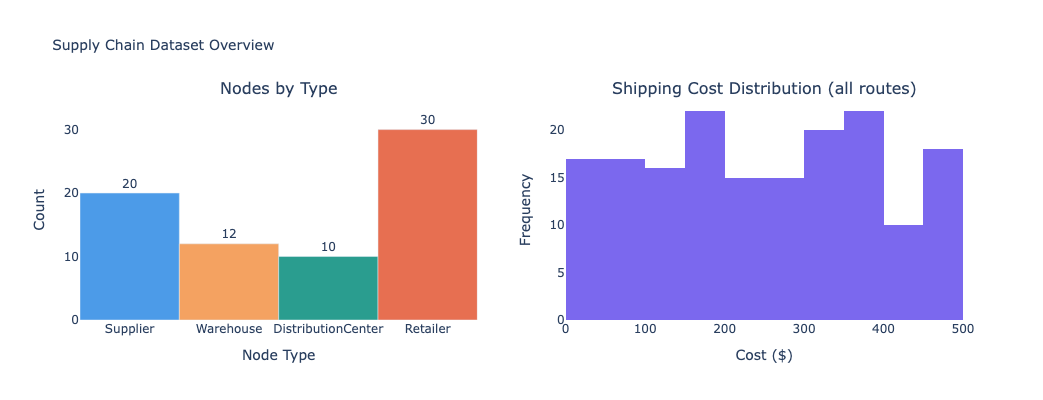

In [7]:
COLOR_MAP = {
    "Supplier":           "#4C9BE8",
    "Warehouse":          "#F4A261",
    "DistributionCenter": "#2A9D8F",
    "Retailer":           "#E76F51",
    "Disrupted":          "#E63946",
}

fig = make_subplots(
    rows = 1, cols = 2,
    subplot_titles = ("Nodes by Type", "Shipping Cost Distribution (all routes)"),
)
node_labels = ["Supplier", "Warehouse", "DistributionCenter", "Retailer"]
node_counts = [len(suppliers), len(warehouses), len(dist_centers), len(retailers)]

fig.add_trace(
    go.Bar(
        x = node_labels, y = node_counts,
        marker_color = [COLOR_MAP[l] for l in node_labels],
        showlegend = False, text = node_counts, textposition = "outside"
    ),
    row = 1, col = 1
)
all_costs = pd.concat([sup_to_wh, wh_to_dc, dc_to_ret])["cost"]
fig.add_trace(
    go.Histogram(x = all_costs, nbinsx = 20, marker_color = "#7B68EE",
                 showlegend = False, name = "Cost"),
    row = 1, col = 2
)
fig.update_layout(
    title = dict(text = "Supply Chain Dataset Overview", font = dict(size = 14)),
    height = 400, plot_bgcolor = "white",
)
fig.update_yaxes(title_text = "Count", row = 1, col = 1)
fig.update_xaxes(title_text = "Node Type", row = 1, col = 1)
fig.update_yaxes(title_text = "Frequency", row = 1, col = 2)
fig.update_xaxes(title_text = "Cost ($)", row = 1, col = 2)
fig.show()

## 5. Load the Graph into Neo4j via Spark

This is where Spark earns its place. We use the Neo4j Spark Connector to write each node type and relationship type directly into Neo4j as a graph.

The connector handles the translation from Spark DataFrames to Cypher MERGE statements under the hood.

In a real pipeline, this step might read from S3, a data warehouse or a Kafka topic and stream millions of records into Neo4j continuously.

In [8]:
# Clear the database before loading to avoid stale data from previous runs
with driver.session(database = NEO4J_DATABASE) as session:
    session.run("""
        MATCH (n)
        CALL (n) { DETACH DELETE n }
        IN TRANSACTIONS OF 10000 ROWS
    """)

print("Database cleared.")

Database cleared.


In [9]:
# Confirm the database is empty before loading
with driver.session(database = NEO4J_DATABASE) as session:
    count = session.run(
        "MATCH (n) RETURN count(n) AS node_count"
    ).single()["node_count"]
    if count == 0:
        print("Database is empty and ready for loading.")
    else:
        print(f"WARNING: {count} nodes still present - clear may have failed.")

Database is empty and ready for loading.


In [10]:
# Load nodes and relationships via Spark
def write_nodes(df, label, node_keys):
    sdf = spark.createDataFrame(df)
    (
        sdf.write.format("org.neo4j.spark.DataSource")
        .mode("Overwrite")
        .option("labels", label)
        .option("node.keys", node_keys)
        .save()
    )
    print(f"  Wrote {df.shape[0]:>3} {label} nodes")

def write_rels(df, rel_type, src_label, src_key, tgt_label, tgt_key):
    sdf = spark.createDataFrame(df)
    (
        sdf.coalesce(1).write.format("org.neo4j.spark.DataSource")
        .mode("Overwrite")
        .option("relationship",               rel_type)
        .option("relationship.save.strategy", "keys")
        .option("relationship.source.labels", src_label)
        .option("relationship.source.node.keys", f"source:{src_key}")
        .option("relationship.target.labels", tgt_label)
        .option("relationship.target.node.keys", f"target:{tgt_key}")
        .save()
    )
    print(f"  Wrote {df.shape[0]:>3} {rel_type} relationships ({src_label} -> {tgt_label})")

print("Writing nodes...")
write_nodes(suppliers,    ":Supplier",           "id")
write_nodes(warehouses,   ":Warehouse",          "id")
write_nodes(dist_centers, ":DistributionCenter", "id")
write_nodes(retailers,    ":Retailer",           "id")

print("\nWriting relationships...")
write_rels(sup_to_wh, "SHIPS_TO", ":Supplier",           "id", ":Warehouse",          "id")
write_rels(wh_to_dc,  "SHIPS_TO", ":Warehouse",          "id", ":DistributionCenter", "id")
write_rels(dc_to_ret, "SHIPS_TO", ":DistributionCenter", "id", ":Retailer",           "id")

print("\nAll data loaded into Neo4j.")

Writing nodes...


  Wrote  20 :Supplier nodes
  Wrote  12 :Warehouse nodes
  Wrote  10 :DistributionCenter nodes
  Wrote  30 :Retailer nodes

Writing relationships...


  Wrote  61 SHIPS_TO relationships (:Supplier -> :Warehouse)
  Wrote  38 SHIPS_TO relationships (:Warehouse -> :DistributionCenter)
  Wrote  73 SHIPS_TO relationships (:DistributionCenter -> :Retailer)

All data loaded into Neo4j.


## 6. Verify the Graph

We'll use the Neo4j Python driver to run a quick Cypher check and confirm all nodes and relationships landed correctly.

In [11]:
with driver.session(database = NEO4J_DATABASE) as session:
    result = session.run(
        "MATCH (n) RETURN labels(n)[0] AS label, count(n) AS count ORDER BY label"
    )
    print("Node counts in Neo4j:")
    for row in result:
        print(f"  {row['label']:<25} {row['count']}")

    result = session.run(
        "MATCH ()-[r]->() RETURN type(r) AS type, count(r) AS count"
    )
    print("\nRelationship counts in Neo4j:")
    for row in result:
        print(f"  {row['type']:<25} {row['count']}")

Node counts in Neo4j:
  DistributionCenter        10
  Retailer                  30
  Supplier                  20
  Warehouse                 12

Relationship counts in Neo4j:
  SHIPS_TO                  172


## 7. Pull the Graph into NetworkX

Now we'll use Spark to read the full graph back out of Neo4j into a Pandas DataFrame, then build a NetworkX graph from it.

This is the hand-off point between Spark (bulk data movement) and NetworkX (graph algorithm computation). For our demo dataset this is instant. At tens of thousands of nodes it's still fine. Beyond that, you would want Neo4j GDS or Aura Graph Analytics to run the algorithm inside the database itself.

In [12]:
edges_sdf = (
    spark.read.format("org.neo4j.spark.DataSource")
    .option("query",
        "MATCH (a)-[r:SHIPS_TO]->(b) "
        "RETURN coalesce(a.id, a.name) AS source, "
        "       coalesce(b.id, b.name) AS target, "
        "       labels(a)[0] AS source_label, "
        "       labels(b)[0] AS target_label, "
        "       r.cost AS cost, r.distance AS distance, r.capacity AS capacity")
    .load()
)
edges_pd = edges_sdf.toPandas()

G = nx.DiGraph()
for _, row in edges_pd.iterrows():
    G.add_node(row["source"], label = row["source_label"])
    G.add_node(row["target"], label = row["target_label"])
    G.add_edge(row["source"], row["target"],
               weight = row["cost"], distance = row["distance"],
               capacity = row["capacity"])

print(f"NetworkX graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

NetworkX graph: 72 nodes, 172 edges


### Visualize the Full Supply Chain Network

Before we run any algorithms, let's look at the raw network structure. Each node type has its own color. Hover over any node to see its ID and type.

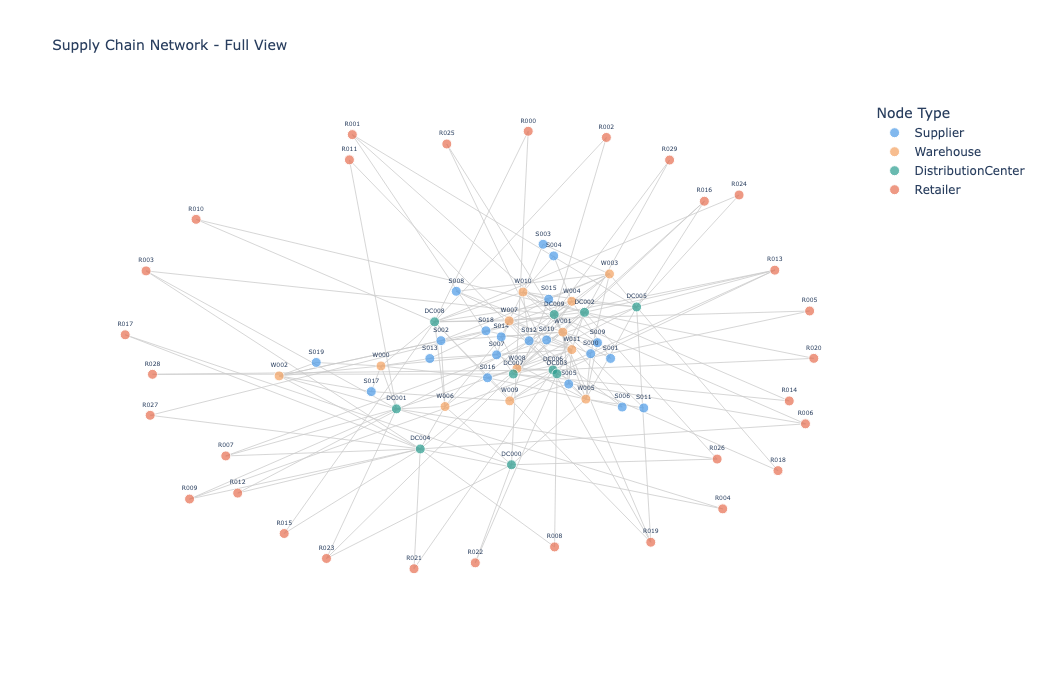

In [13]:
def build_network_figure(G, highlight_node = None, highlight_path = None,
                         title = "Supply Chain Network"):
    """Build a Plotly figure from a NetworkX graph.
    Optionally highlight a disrupted node (red) and a path (green edges).
    """
    pos = nx.spring_layout(G, seed = RANDOM_SEED, k = 1.8)

    path_edges = set(zip(highlight_path, highlight_path[1:])) if highlight_path else set()
    ex_n, ey_n, ex_p, ey_p = [], [], [], []
    for u, v in G.edges():
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        if (u, v) in path_edges or (v, u) in path_edges:
            ex_p += [x0, x1, None]
            ey_p += [y0, y1, None]
        else:
            ex_n += [x0, x1, None]
            ey_n += [y0, y1, None]

    traces = [go.Scatter(
        x = ex_n, y = ey_n, mode = "lines",
        line = dict(width = 0.8, color = "#cccccc"),
        hoverinfo = "none", showlegend = False
    )]
    if ex_p:
        traces.append(go.Scatter(
            x = ex_p, y = ey_p, mode = "lines",
            line = dict(width = 3, color = "#2ECC71"),
            hoverinfo = "none", name = "Alternative Route"
        ))

    grouped = {}
    for node in G.nodes():
        lbl = "Disrupted" if node == highlight_node else G.nodes[node].get("label", "Unknown")
        grouped.setdefault(lbl, []).append(node)

    for lbl, nodes in grouped.items():
        traces.append(go.Scatter(
            x = [pos[n][0] for n in nodes],
            y = [pos[n][1] for n in nodes],
            mode = "markers+text",
            marker = dict(
                size = [18 if n == highlight_node else 10 for n in nodes],
                color = COLOR_MAP.get(lbl, "#999"),
                line = dict(width = 1, color = "white")
            ),
            text = nodes,
            textposition = "top center",
            textfont = dict(size = 6),
            hovertext = [f"{n}<br>Type: {lbl}" for n in nodes],
            hoverinfo = "text",
            name = lbl
        ))

    return go.Figure(
        data = traces,
        layout = go.Layout(
            title = dict(text = title, font = dict(size = 14)),
            showlegend = True,
            legend_title_text = "Node Type",
            hovermode = "closest",
            height = 680,
            xaxis = dict(showgrid = False, zeroline = False, showticklabels = False),
            yaxis = dict(showgrid = False, zeroline = False, showticklabels = False),
            plot_bgcolor = "white"
        )
    )

build_network_figure(G, title='Supply Chain Network - Full View').show()

## 8. Betweenness Centrality - Who is Critical?

Betweenness centrality answers a specific question: if we looked at every possible shortest path between every pair of nodes in the network, how often does each node appear on one of those paths?

A node with high betweenness is a bridge. Traffic flows through it constantly. If it disappears, many routes break. A node with low betweenness is peripheral - the network barely notices if it goes offline.

We'll compute this with NetworkX using `cost` as the edge weight, so the algorithm finds shortest paths by lowest shipping cost rather than fewest hops.

> **Note:** `nx.betweenness_centrality()` runs in O(n * m) time where n is nodes and m is edges. For our demo graph this is instantaneous. For a 50,000-node supply chain you would want Neo4j GDS (`gds.betweenness.stream()`) or Aura Graph Analytics, which run the algorithm inside the database using advanced processing.

In [14]:
centrality = nx.betweenness_centrality(G, weight = "cost", normalized = True)

centrality_df = pd.DataFrame([
    {
        "node_id":    node,
        "label":      G.nodes[node].get("label", "Unknown"),
        "centrality": round(score, 4),
    }
    for node, score in centrality.items()
]).sort_values("centrality", ascending = False).reset_index(drop = True)

print("Top 10 nodes by betweenness centrality:")
print(centrality_df.head(10).to_string(index = False))

Top 10 nodes by betweenness centrality:
node_id              label  centrality
  DC008 DistributionCenter      0.0238
  DC009 DistributionCenter      0.0209
  DC002 DistributionCenter      0.0199
  DC005 DistributionCenter      0.0177
   W011          Warehouse      0.0173
   W005          Warehouse      0.0171
   W001          Warehouse      0.0144
   W010          Warehouse      0.0144
  DC004 DistributionCenter      0.0141
  DC006 DistributionCenter      0.0131


### Visualize Centrality Scores

The bar chart below shows the top 15 nodes. A long bar means the network depends heavily on that node - it sits on the shortest path between many pairs of other nodes. Hover to see exact scores.

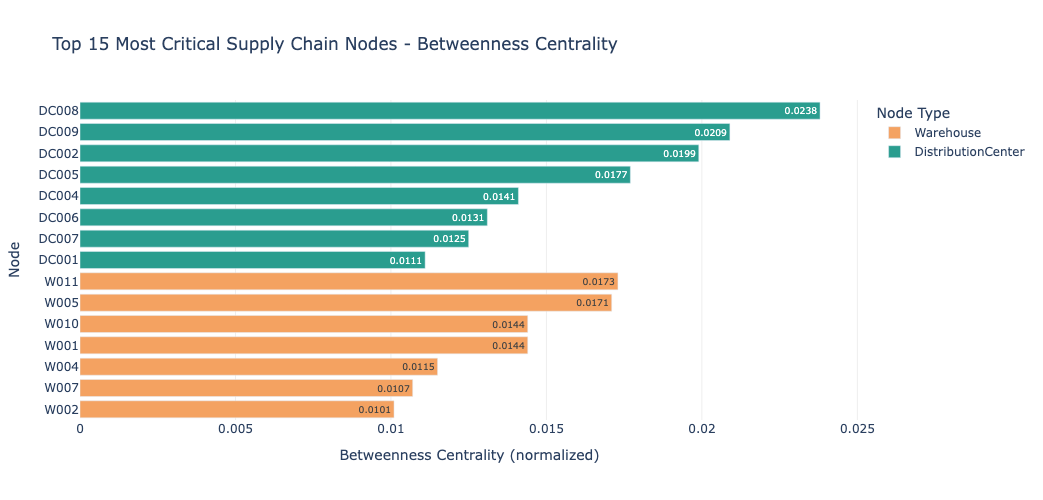

In [15]:
top15 = centrality_df.head(15).sort_values("centrality")

fig = px.bar(
    top15,
    x = "centrality",
    y = "node_id",
    color = "label",
    color_discrete_map = COLOR_MAP,
    orientation = "h",
    title = "Top 15 Most Critical Supply Chain Nodes - Betweenness Centrality",
    labels = {
        "centrality": "Betweenness Centrality (normalized)",
        "node_id": "Node",
        "label": "Type"
    },
    text_auto = ".4f",
)

fig.update_layout(
    height = 500,
    plot_bgcolor = "white",
    legend_title_text = "Node Type",
    xaxis=dict(gridcolor = "#eeeeee"),
)

fig.show()

### Write Centrality Scores Back to Neo4j

Now Spark plays its role again - we'll write the centrality scores computed by NetworkX back into Neo4j as node properties. This enriches the graph so Cypher queries can use centrality as a filter or sort key later, without recomputing it every time.

In [16]:
with driver.session(database = NEO4J_DATABASE) as session:
    for row in centrality_df.itertuples():
        session.run(
            "MATCH (n {id: $id}) SET n.betweenness = $score",
            id = row.node_id, score = row.centrality
        )

print(f"Betweenness scores written to Neo4j for {len(centrality_df)} nodes.")

Betweenness scores written to Neo4j for 72 nodes.


## 9. Simulate a Disruption

We'll take the highest-centrality node that is a Supplier or Warehouse and simulate it going offline - a factory shutdown, a warehouse fire or a port strike. We'll deliberately avoid disrupting a Distribution Center, as their smaller count makes them more likely to be sole bridges in the network, leaving no viable alternative routes at all.

We'll mark the node as disrupted in Neo4j so subsequent queries can exclude it naturally. This is the moment the network visualization becomes telling: one node disappears and we need to understand what that does to the routes that depended upon it.

Disrupted node : W011
Type           : Warehouse
Centrality     : 0.0173

Node W011 marked as disrupted in Neo4j.


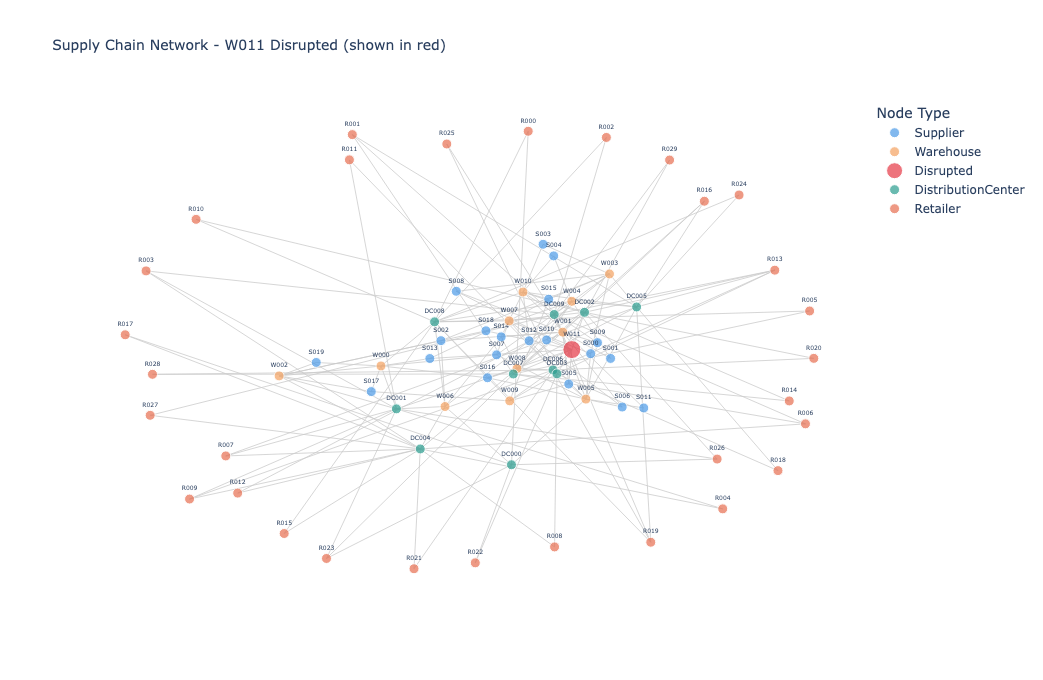

In [17]:
# Clear any disruption flags left from a previous run
with driver.session(database = NEO4J_DATABASE) as session:
    session.run("MATCH (n {disrupted: true}) REMOVE n.disrupted")

# Restrict disruption to Suppliers and Warehouses for network robustness
candidate_df = centrality_df[
    centrality_df["label"].isin(["Supplier", "Warehouse"])
].reset_index(drop = True)

disrupted_id    = candidate_df.iloc[0]["node_id"]
disrupted_label = candidate_df.iloc[0]["label"]
disrupted_score = candidate_df.iloc[0]["centrality"]

print(f"Disrupted node : {disrupted_id}")
print(f"Type           : {disrupted_label}")
print(f"Centrality     : {disrupted_score:.4f}")

with driver.session(database = NEO4J_DATABASE) as session:
    session.run(
        "MATCH (n {id: $id}) SET n.disrupted = true",
        id = disrupted_id
    )

print(f"\nNode {disrupted_id} marked as disrupted in Neo4j.")

build_network_figure(
    G,
    highlight_node = disrupted_id,
    title = f"Supply Chain Network - {disrupted_id} Disrupted (shown in red)"
).show()

### Disruption Impact - Routes Lost

Before we look at alternatives, let's quantify the impact of the disruption. How many direct routes passed through the disrupted node and how many supplier-retailer pairs are now affected?

Disrupted node    : W011 (Warehouse)
Inbound routes    : 6
Outbound routes   : 4
Total routes lost : 10

Supplier-retailer pairs total       : 600
Pairs still reachable after disruption: 503
Pairs now unreachable                 : 97


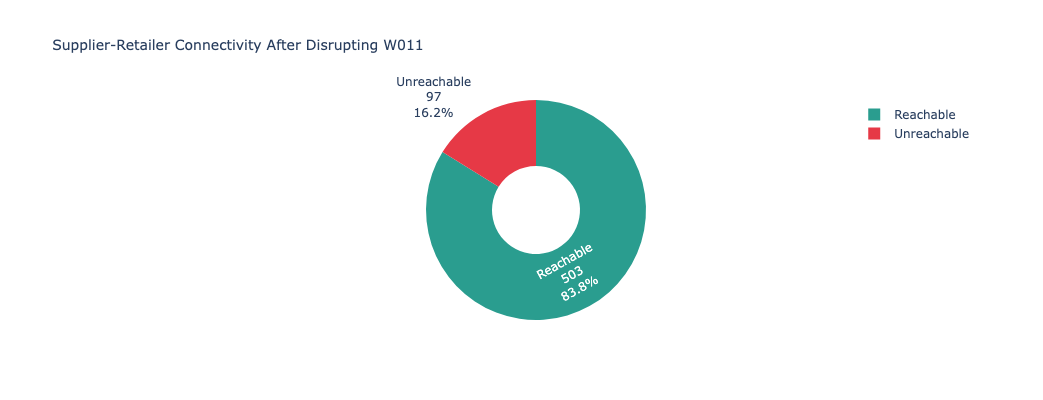

In [18]:
# Count routes through the disrupted node before disruption
in_edges  = [(u, v) for u, v in G.in_edges(disrupted_id)]
out_edges = [(u, v) for u, v in G.out_edges(disrupted_id)]

print(f"Disrupted node    : {disrupted_id} ({disrupted_label})")
print(f"Inbound routes    : {len(in_edges)}")
print(f"Outbound routes   : {len(out_edges)}")
print(f"Total routes lost : {len(in_edges) + len(out_edges)}")

# Count supplier-retailer pairs now unreachable
G_disrupted = G.copy()
G_disrupted.remove_node(disrupted_id)

supplier_ids = suppliers["id"].tolist()
retailer_ids = retailers["id"].tolist()
total_pairs      = 0
unreachable_pairs = 0

for s in supplier_ids:
    for r in retailer_ids:
        if s in G_disrupted and r in G_disrupted:
            total_pairs += 1
            if not nx.has_path(G_disrupted, s, r):
                unreachable_pairs += 1

reachable_pairs = total_pairs - unreachable_pairs
print(f"\nSupplier-retailer pairs total       : {total_pairs}")
print(f"Pairs still reachable after disruption: {reachable_pairs}")
print(f"Pairs now unreachable                 : {unreachable_pairs}")

# Visualize impact
fig = go.Figure(go.Pie(
    labels = ["Reachable", "Unreachable"],
    values = [reachable_pairs, unreachable_pairs],
    marker_colors = ["#2A9D8F", "#E63946"],
    hole = 0.4,
    textinfo = "label+percent+value",
))
fig.update_layout(
    title = dict(
        text = f"Supplier-Retailer Connectivity After Disrupting {disrupted_id}",
        font = dict(size = 14)
    ),
    height = 400,
)
fig.show()

### Which Node Type Bears the Most Risk?

The grouped bar chart below compares total, average and peak betweenness centrality across all four node types. This shows not just which type carries the most routing burden in aggregate, but also whether that burden is spread evenly or concentrated in a small number of critical nodes.

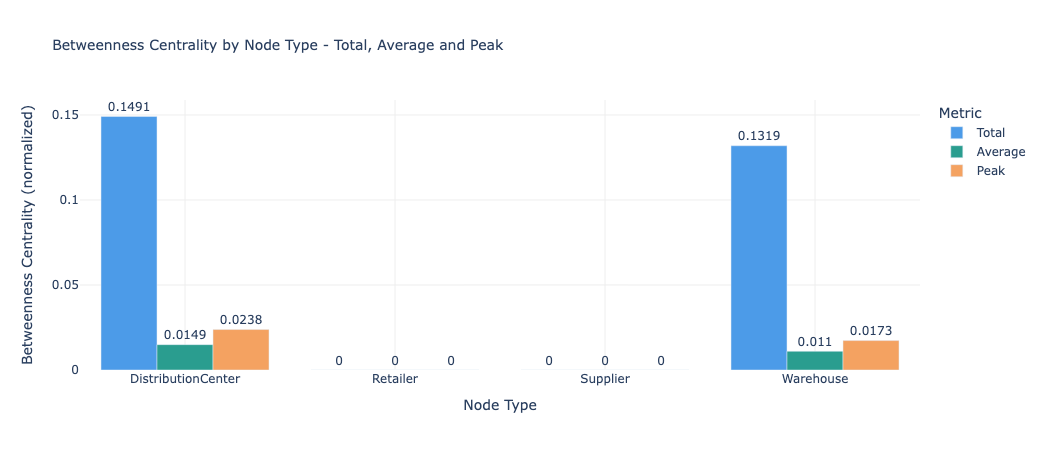

In [19]:
type_centrality = (
    centrality_df.groupby("label")["centrality"]
    .agg(["sum", "mean", "max"])
    .reset_index()
    .rename(columns = {"sum": "Total", "mean": "Average", "max": "Peak"})
)

fig = go.Figure()

for metric, color in [
    ("Total",   "#4C9BE8"),
    ("Average", "#2A9D8F"),
    ("Peak",    "#F4A261"),
]:
    fig.add_trace(go.Bar(
        name = metric,
        x = type_centrality["label"],
        y = type_centrality[metric],
        marker_color = color,
        text = type_centrality[metric].round(4),
        textposition = "outside",
    ))

fig.update_layout(
    title = dict(
        text = "Betweenness Centrality by Node Type - Total, Average and Peak",
        font = dict(size = 14)
    ),
    barmode = "group",
    height = 450,
    plot_bgcolor = "white",
    xaxis = dict(title = "Node Type", gridcolor = "#eeeeee"),
    yaxis = dict(title = "Betweenness Centrality (normalized)", gridcolor = "#eeeeee"),
    legend_title_text = "Metric",
)
fig.show()

## 10. Find Alternative Routes - Native Cypher Variable-Length Path

With the critical node marked as disrupted, we'll now ask Neo4j to find alternative routes that avoid it. We'll use Neo4j's native variable-length path matching, which is available on both local Neo4j and AuraDB with no additional plugins required.

We'll find the ten cheapest end-to-end routes from suppliers to retailers, excluding the disrupted node. This gives a full picture of how the network reroutes around the failure.

> **Note:** The path match uses an upper bound on hops (`*..6`) to keep the query efficient - this is a Cypher requirement, not a limitation of our data.

In [20]:
with driver.session(database = NEO4J_DATABASE) as session:
    result = session.run("""
        MATCH (s:Supplier), (r:Retailer)
        WHERE s.disrupted IS NULL
          AND r.disrupted IS NULL
        MATCH path = (s)-[:SHIPS_TO*..6]->(r)
        WHERE none(n IN nodes(path) WHERE n.disrupted IS NOT NULL AND n.disrupted = true)
        WITH s, r, path,
             reduce(
                 cost = 0.0,
                 rel IN relationships(path) | cost + rel.cost
             ) AS total_cost
        ORDER BY total_cost ASC
        RETURN
            s.id AS source,
            r.id AS target,
            [n IN nodes(path) | coalesce(n.id, n.name)] AS path_nodes,
            [n IN nodes(path) | labels(n)[0]]           AS path_labels,
            round(total_cost, 2)                        AS total_cost,
            length(path)                                AS hops
        LIMIT 10
    """)
    alt_routes = [dict(r) for r in result]

alt_df = pd.DataFrame(alt_routes)
print(f"Found {len(alt_df)} alternative routes.")
if not alt_df.empty:
    print(alt_df[["source", "target", "total_cost", "hops"]].to_string(index = False))
else:
    print("No routes found - the disrupted node may be a sole bridge. "
          "Try re-running from Section 4 with a larger dataset.")

Found 10 alternative routes.
source target  total_cost  hops
  S006   R001       94.35     3
  S007   R026      148.86     3
  S007   R017      155.19     3
  S019   R026      165.88     3
  S019   R017      172.21     3
  S018   R026      175.93     3
  S018   R017      182.26     3
  S006   R027      185.71     3
  S007   R009      186.38     3
  S007   R007      199.39     3


### Visualize the Best Alternative Route

The network diagram below highlights the cheapest alternative route in green, with the disrupted node still shown in red. This is the rerouting the supply chain would follow if the critical node went offline.

Best alternative route: S006 -> R001
Path  : S006 -> W005 -> DC009 -> R001
Cost  : $94.35
Hops  : 3


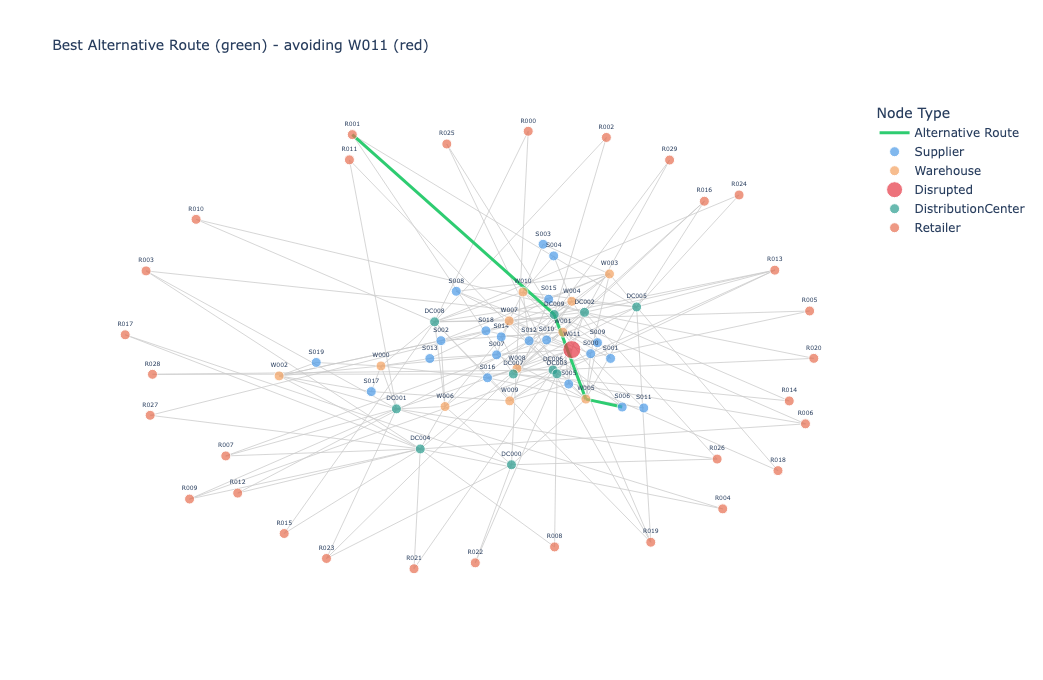

In [21]:
if alt_df.empty:
    print("No alternative routes to visualize.")
else:
    best       = alt_df.iloc[0]
    path_nodes = best["path_nodes"]
    path_str   = " -> ".join(path_nodes)

    print(f"Best alternative route: {best['source']} -> {best['target']}")
    print(f"Path  : {path_str}")
    print(f"Cost  : ${best['total_cost']}")
    print(f"Hops  : {best['hops']}")

    build_network_figure(
        G,
        highlight_node = disrupted_id,
        highlight_path = path_nodes,
        title = f"Best Alternative Route (green) - avoiding {disrupted_id} (red)"
    ).show()

### Route Cost Comparison

How do the top alternative routes compare by cost and number of hops? A route with more hops may still be cheaper - a useful insight for logistics planning.

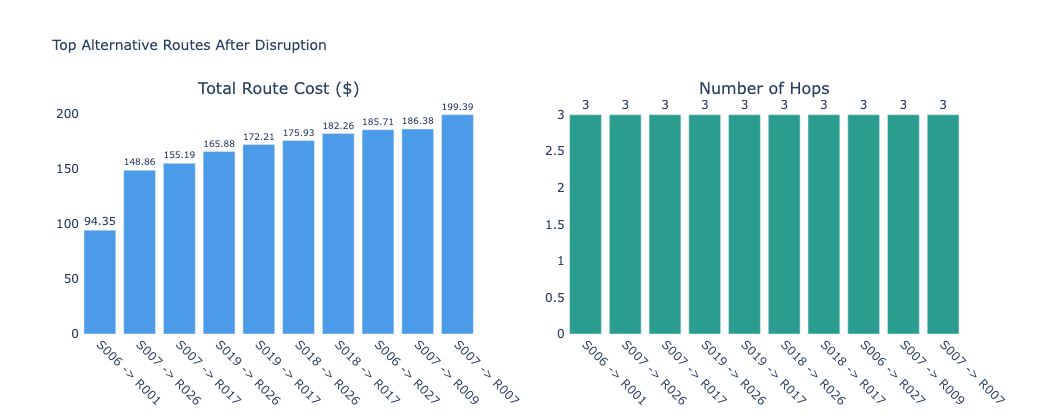

In [22]:
if alt_df.empty:
    print("No alternative routes to compare.")
else:
    alt_df["route"] = alt_df["source"] + " -> " + alt_df["target"]
    fig = make_subplots(
        rows = 1, cols = 2,
        subplot_titles = ("Total Route Cost ($)", "Number of Hops")
    )
    fig.add_trace(
        go.Bar(
            x = alt_df["route"], y = alt_df["total_cost"],
            marker_color = "#4C9BE8", showlegend = False,
            text = alt_df["total_cost"], textposition = "outside"
        ),
        row = 1, col = 1
    )
    fig.add_trace(
        go.Bar(
            x = alt_df["route"], y = alt_df["hops"],
            marker_color = "#2A9D8F", showlegend = False,
            text = alt_df["hops"], textposition = "outside"
        ),
        row = 1, col = 2
    )
    fig.update_layout(
        title = dict(text = "Top Alternative Routes After Disruption", font = dict(size = 14)),
        height = 420, plot_bgcolor = "white",
    )
    fig.update_xaxes(tickangle = 45)
    fig.show()

## 11. Teardown

Close all connections and stop Spark.

In [23]:
driver.close()
spark.stop()
print("Connections closed. Spark stopped.")

Connections closed. Spark stopped.


## 12. Scaling Up - When NetworkX Is Not Enough

Everything we've done here works well at demo scale. But what happens when your supply chain has 500,000 nodes and 2 million routes?

**The NetworkX bottleneck:**
Betweenness centrality requires loading the entire graph into memory and running an O(n * m) algorithm. At scale, this becomes impractical - both in memory and in time.

**The Neo4j answer:**
Neo4j's Graph Data Science (GDS) library runs betweenness centrality natively inside the database using advanced processing. The same algorithm that took NetworkX minutes on a large graph runs in seconds in GDS, without moving any data out of Neo4j.

**On AuraDB:**
If you are using Neo4j AuraDB (the managed cloud service), GDS is available as **Aura Graph Analytics** - a pay-as-you-go service that connects directly to your AuraDB instance. You get the same algorithms without managing any infrastructure.

The rest of the notebook - Spark for data loading, Plotly for visualization and native Cypher for shortest path - all work identically on AuraDB.

## 13. Summary

In this notebook we:

1. Generated a reproducible synthetic supply chain with Faker and NumPy
2. Loaded it into Neo4j via Apache Spark and the Neo4j Spark Connector
3. Computed betweenness centrality with NetworkX to identify the most critical node in the network
4. Wrote those scores back into Neo4j for later use in Cypher queries
5. Simulated a real-world disruption by marking that node offline
6. Used Neo4j's native variable-length path matching to find alternative routes - no plugins required, works on both local Neo4j and AuraDB
7. Visualized every stage interactively with Plotly